In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

def load_dataset():
    df = pd.read_csv(DATA_URL, sep="\t", names=["label", "message"])
    return df

def preprocess_labels(df):
    df["label"] = df["label"].map({"ham":0, "spam":1})
    return df

def split_data(df, test_size=0.2, random_state=42):
    
    X = df["message"]
    y = df["label"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test

def get_processed_data():
    
    df = load_dataset()
    df = preprocess_labels(df)

    X_train, X_test, y_train, y_test = split_data(df)

    return X_train, X_test, y_train, y_test

In [2]:
X_train, X_test, y_train, y_test = get_processed_data()

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_vec, y_train)

KNeighborsClassifier()

In [5]:
knn_pred = knn_model.predict(X_test_vec)

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [7]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

Confusion Matrix:
[[966   0]
 [ 97  52]]


In [8]:
print("Accuracy:", accuracy_score(y_test, knn_pred))

Accuracy: 0.9130044843049328


In [9]:
print("Precision:", precision_score(y_test, knn_pred))

Precision: 1.0


In [10]:
print("Recall:", recall_score(y_test, knn_pred))

Recall: 0.348993288590604


In [11]:
print("F1 Score:", f1_score(y_test, knn_pred))

F1 Score: 0.5174129353233831


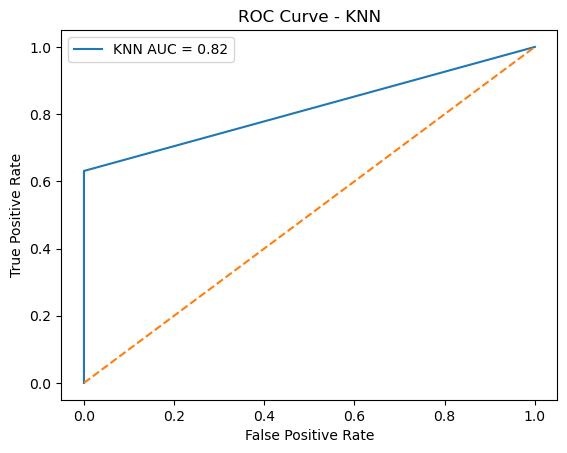

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

scores = knn_model.predict_proba(X_test_vec)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, scores)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="KNN AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()

plt.show()

In [13]:
import time

start = time.time()

knn_model.fit(X_train_vec, y_train)

train_time = time.time() - start

print("Training Time:", train_time)

Training Time: 0.003617525100708008


In [14]:
start = time.time()

knn_pred = knn_model.predict(X_test_vec)

test_time = time.time() - start

print("Testing Time:", test_time)

Testing Time: 0.20089101791381836
